<a href="https://colab.research.google.com/github/MiguelGonzalez197/Proyecto_IA-Ecomision/blob/Miguel/ProyectoEcomision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
# Librerias
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# Cargar Dataset
dataset_path = "/content/drive/MyDrive/ProyectoIA-Ecomision/dataset"

img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 104 files belonging to 3 classes.
Using 84 files for training.
Found 104 files belonging to 3 classes.
Using 20 files for validation.


In [20]:
# Agregar Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])


In [21]:
#Crear modelo con Transfer Learning
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # congelamos capas

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

In [22]:
# Compilar modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# Entrenar
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3919 - loss: 1.4654 - val_accuracy: 0.7500 - val_loss: 0.5656
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8188 - loss: 0.5662 - val_accuracy: 0.8500 - val_loss: 0.3764
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8506 - loss: 0.4322 - val_accuracy: 0.8000 - val_loss: 0.4145
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9232 - loss: 0.2483 - val_accuracy: 0.8500 - val_loss: 0.3088
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9116 - loss: 0.2088 - val_accuracy: 0.9000 - val_loss: 0.1696
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9725 - loss: 0.1014 - val_accuracy: 0.9500 - val_loss: 0.1295
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.9587 - loss: 0.1237 - val_accuracy: 0.9000 - val_loss: 0.1632
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9901 - loss: 0.0578 - val_accuracy: 0.9000 - val_loss: 0.1966
Epoch 9/10
3/3

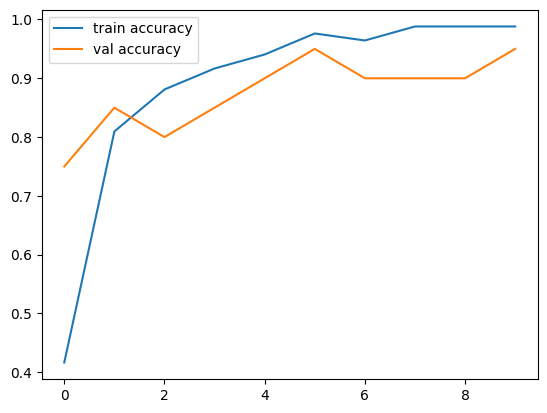

In [24]:
# Ver resultados
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

In [27]:
# Probar manualmente modelo
class_names = train_ds.class_names

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print("Predicción:", class_names[np.argmax(score)])
    print("Confianza:", 100 * np.max(score), "%")

In [28]:
predict_image("/content/drive/MyDrive/ProyectoIA-Ecomision/imagenes_prueba/Aprovechable_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicción: aprovechable
Confianza: 57.59132 %


In [29]:
# Guardar modelo
model.save("/content/drive/MyDrive/ProyectoIA-Ecomision/modelo_ecomision.h5")

In [15]:
# Cargar modelo

model = load_model("/content/drive/MyDrive/ProyectoIA-Ecomision/modelo_ecomision.h5")